In [32]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np


In [3]:

df = pd.read_csv('complete.csv', engine='python', on_bad_lines='skip')
print(df.shape)


(88679, 11)


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (88679, 11)

Column Names:
Index(['datetime', 'city', 'state', 'country', 'shape', 'duration (seconds)',
       'duration (hours/min)', 'comments', 'date posted', 'latitude',
       'longitude'],
      dtype='str')

Data Types:
datetime                    str
city                        str
state                       str
country                     str
shape                       str
duration (seconds)          str
duration (hours/min)        str
comments                    str
date posted                 str
latitude                    str
longitude               float64
dtype: object

Missing Values:
datetime                    0
city                        0
state                    7409
country                 12365
shape                    2922
duration (seconds)          2
duration (hours/min)     3019
comments                   35
date posted                 0
latitude                    0
longitude                   0
dtype: int64


In [5]:
# Convert datetime column
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

# Extract useful time features
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour

# Check results
print(df[['datetime', 'year', 'month', 'hour']].head())

# Check missing values created during conversion
print("\nMissing datetime values:")
print(df['datetime'].isnull().sum())

             datetime    year  month  hour
0 1949-10-10 20:30:00  1949.0   10.0  20.0
1 1949-10-10 21:00:00  1949.0   10.0  21.0
2 1955-10-10 17:00:00  1955.0   10.0  17.0
3 1956-10-10 21:00:00  1956.0   10.0  21.0
4 1960-10-10 20:00:00  1960.0   10.0  20.0

Missing datetime values:
1220


In [6]:
# Remove rows with invalid datetime
df = df.dropna(subset=['datetime'])

# Confirm removal
print("Dataset shape after datetime cleaning:", df.shape)

Dataset shape after datetime cleaning: (87459, 14)


In [7]:
# Convert duration to numeric (temporary inspection)
df['duration_seconds'] = pd.to_numeric(df['duration (seconds)'], errors='coerce')

# Basic inspection
print(df['duration_seconds'].describe())

# Count missing after conversion
print("\nMissing duration values:")
print(df['duration_seconds'].isnull().sum())

count    8.745400e+04
mean     7.569762e+03
std      5.668348e+05
min      0.000000e+00
25%      1.500000e+01
50%      1.200000e+02
75%      6.000000e+02
max      9.783600e+07
Name: duration_seconds, dtype: float64

Missing duration values:
5


In [8]:
# Keep original column for reference
df['duration_seconds_original'] = df['duration_seconds']

# Apply cleaning to a new column
df['duration_seconds_clean'] = df['duration_seconds'].clip(lower=1, upper=86400)

print("Comparison:")
print(f"Original - Min: {df['duration_seconds'].min()}, Max: {df['duration_seconds'].max()}")
print(f"Cleaned  - Min: {df['duration_seconds_clean'].min()}, Max: {df['duration_seconds_clean'].max()}")
print(f"Records affected: {(df['duration_seconds'] != df['duration_seconds_clean']).sum()}")

Comparison:
Original - Min: 0.0, Max: 97836000.0
Cleaned  - Min: 1.0, Max: 86400.0
Records affected: 6792


In [9]:
# Calculate exact breakdown
n_zero_or_less = (df['duration_seconds'] <= 0).sum()
n_over_24h = (df['duration_seconds'] > 86400).sum()
n_missing = df['duration_seconds'].isnull().sum()

print(f"Detailed breakdown of affected records:")
print(f"- Zero or negative duration: {n_zero_or_less}")
print(f"- Over 24 hours: {n_over_24h}")
print(f"- Missing values: {n_missing}")
print(f"- Total affected: {n_zero_or_less + n_over_24h + n_missing}")

# Calculate percentages
total_records = len(df)
print(f"\nPercentage of data affected: {(6792/total_records)*100:.2f}%")

Detailed breakdown of affected records:
- Zero or negative duration: 6525
- Over 24 hours: 172
- Missing values: 5
- Total affected: 6702

Percentage of data affected: 7.77%


In [10]:
# Optional: Look at extreme cases
print("\nExtreme cases (>24 hours):")
extremes = df[df['duration_seconds'] > 86400]
print(f"Count: {len(extremes)}")
print(f"Top 5 longest durations:")
print(extremes.nlargest(5, 'duration_seconds')[['datetime', 'duration_seconds', 'comments']])

# Check if extreme durations correlate with other factors
if 'shape' in df.columns:
    print("\nShapes of extreme duration sightings:")
    print(extremes['shape'].value_counts())


Extreme cases (>24 hours):
Count: 172
Top 5 longest durations:
                 datetime  duration_seconds  \
609   1983-10-01 17:00:00        97836000.0   
59230 2010-06-03 23:30:00        82800000.0   
82460 1991-09-15 18:00:00        66276000.0   
71242 2012-08-10 21:00:00        52623200.0   
76506 2002-08-24 01:00:00        52623200.0   

                                                comments  
609    Firstly&#44 I was stunned and stared at the ob...  
59230  ((HOAX??))  I was out in a field near mil&#44 ...  
82460  Orange or amber balls or orbs of light multipl...  
71242  There have been several flying objects in a pe...  
76506  bright stars&#44 moving erratically&#44 over t...  

Shapes of extreme duration sightings:
shape
light        32
unknown      20
other        18
circle       15
disk         12
triangle     12
sphere       11
oval          8
cigar         5
changing      4
cylinder      4
fireball      4
egg           4
formation     3
diamond       2
cone          

In [ ]:
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')

print("\nInvalid coordinates check:")
print(f"Null latitude: {df['latitude'].isnull().sum()}")
print(f"Null longitude: {df['longitude'].isnull().sum()}")

invalid_lat = ((df['latitude'] < -90) | (df['latitude'] > 90)).sum()
invalid_lon = ((df['longitude'] < -180) | (df['longitude'] > 180)).sum()
print(f"Invalid latitude: {invalid_lat}")
print(f"Invalid longitude: {invalid_lon}")

categorical_cols = ['city', 'state', 'country', 'shape']
for col in categorical_cols:
    print(f"\n--- {col.upper()} ---")
    print(f"Unique values: {df[col].nunique()}")
    print(f"Missing: {df[col].isnull().sum()}")
    print(f"Top 10 most common:")
    print(df[col].value_counts().head(10))

if 'comments' in df.columns:
    print(f"\n--- COMMENTS ---")
    print(f"Total comments: {len(df['comments'])}")
    print(f"Missing comments: {df['comments'].isnull().sum()}")
    print(f"Average comment length: {df['comments'].str.len().mean():.0f} chars")
    print("\nSample comments:")
    print(df['comments'].head(3).tolist())


Invalid coordinates check:
Null latitude: 1
Null longitude: 0
Invalid latitude: 0
Invalid longitude: 0

--- CITY ---
Unique values: 21712
Missing: 0
Top 10 most common:
city
seattle        562
phoenix        482
portland       397
las vegas      394
los angeles    369
san diego      358
houston        312
chicago        292
tucson         257
miami          256
Name: count, dtype: int64

--- STATE ---
Unique values: 68
Missing: 7189
Top 10 most common:
state
ca    10332
wa     4594
fl     4551
tx     3978
ny     3465
az     2901
il     2844
pa     2755
oh     2602
mi     2233
Name: count, dtype: int64

--- COUNTRY ---
Unique values: 5
Missing: 12043
Top 10 most common:
country
us    69496
ca     3228
gb     2001
au      583
de      108
Name: count, dtype: int64

--- SHAPE ---
Unique values: 28
Missing: 2660
Top 10 most common:
shape
light        17741
triangle      8418
circle        8343
fireball      6509
unknown       6219
other         6164
disk          5879
sphere        5698
ov

## 1. Convert string columns to appropriate types
## 2. Check for invalid coordinates
## Valid latitude range: -90 to 90 and longitude range: -180 to 180
## 3. Check categorical columns
## 4. Text data in comments

In [25]:
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df = df.dropna(subset=['latitude', 'longitude'])


In [26]:
# Create clustering features
clustering_features = df[['latitude', 'longitude', 'year', 'month', 'hour', 'duration_seconds_clean']].copy()

# Standardize numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(clustering_features)

print(f"Features shape for clustering: {features_scaled.shape}")

Features shape for clustering: (87458, 6)


In [42]:
# Remove any remaining NaN rows from selected features
features = features.dropna()

print("Feature shape after final NaN removal:", features.shape)
print(features.isnull().sum())


Feature shape after final NaN removal: (87453, 4)
latitude            0
longitude           0
hour                0
duration_seconds    0
dtype: int64


In [43]:
# 1. Check which features have NaN values
print("Checking for NaN in clustering features:")
for col in ['latitude', 'longitude', 'year', 'month', 'hour', 'duration_seconds_clean']:
    nan_count = df[col].isnull().sum()
    print(f"{col}: {nan_count} NaN values")

# 2. Remove rows with any NaN in these columns
df_clean = df.dropna(subset=['latitude', 'longitude', 'year', 'month', 'hour', 'duration_seconds_clean'])

print(f"\nOriginal dataset: {len(df)} rows")
print(f"After removing NaN: {len(df_clean)} rows")
print(f"Rows removed: {len(df) - len(df_clean)}")

# 3. Create clean features array
clustering_features = df_clean[['latitude', 'longitude', 'year', 'month', 'hour', 'duration_seconds_clean']].copy()

# 4. Scale the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(clustering_features)

print(f"\nFeatures shape for clustering: {features_scaled.shape}")
print(f"Any NaN in scaled features? {np.isnan(features_scaled).any()}")

Checking for NaN in clustering features:
latitude: 0 NaN values
longitude: 0 NaN values
year: 0 NaN values
month: 0 NaN values
hour: 0 NaN values
duration_seconds_clean: 5 NaN values

Original dataset: 87458 rows
After removing NaN: 87453 rows
Rows removed: 5

Features shape for clustering: (87453, 6)
Any NaN in scaled features? False


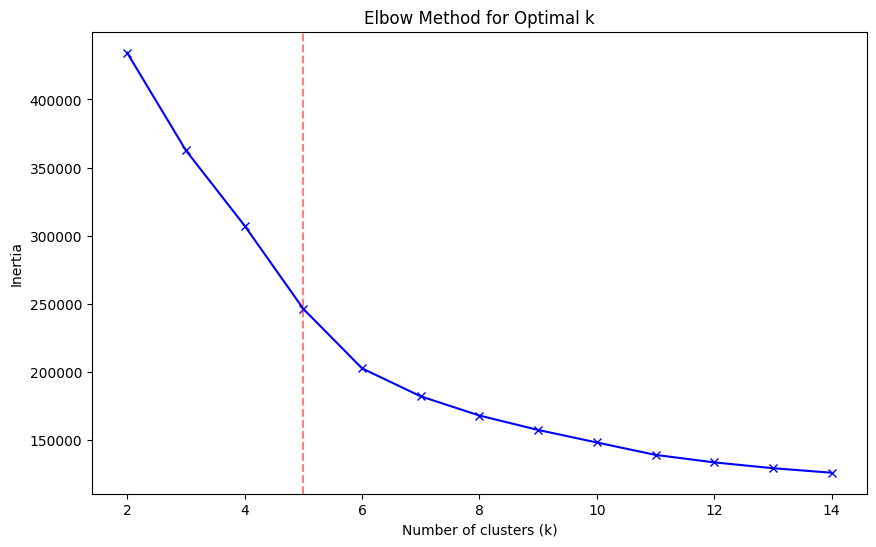

In [44]:
# Elbow method to find optimal k
inertias = []
k_range = range(2, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10,6))
plt.plot(k_range, inertias, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.axvline(x=5, color='red', linestyle='--', alpha=0.5)  # Common optimal
plt.show()

k=2, silhouette=0.568
k=3, silhouette=0.293
k=4, silhouette=0.283
k=5, silhouette=0.310
k=6, silhouette=0.285
k=7, silhouette=0.297
k=8, silhouette=0.286
k=9, silhouette=0.290
k=10, silhouette=0.293


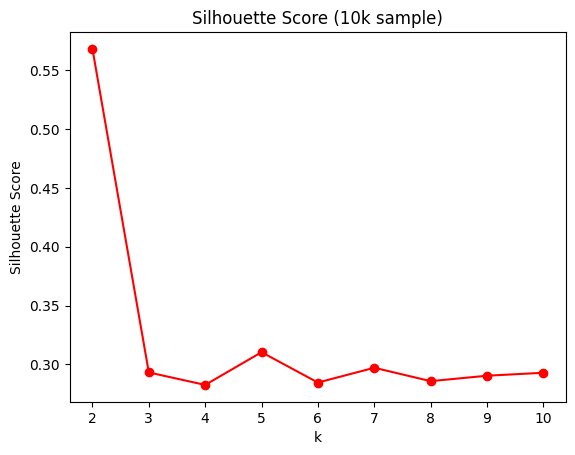

In [45]:
import numpy as np


# Take a random sample of 10,000 rows
sample_idx = np.random.choice(len(features_scaled), size=10000, replace=False)
X_sample = features_scaled[sample_idx]

silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    silhouette_scores.append(score)
    print(f"k={k}, silhouette={score:.3f}")

# Plot
plt.plot(k_range, silhouette_scores, 'ro-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score (10k sample)')
plt.show()

In [46]:
optimal_k = 5  # change if silhouette suggests otherwise
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(features_scaled)

print("Cluster sizes:")
print(df_clean['cluster'].value_counts().sort_index())

Cluster sizes:
cluster
0    22037
1     3305
2      255
3    55704
4     6152
Name: count, dtype: int64


In [47]:
# Add cluster labels to the main dataframe
df_result = df_clean.copy()  # df_clean already has features + cluster
# (Alternatively, merge back with original df to include categorical columns)

# Merge with original df to get shape, country, etc.
df_result_full = df.loc[df_clean.index].copy()
df_result_full['cluster'] = df_clean['cluster']

# Cluster profiles
cluster_profile = df_result_full.groupby('cluster').agg({
    'latitude': 'mean',
    'longitude': 'mean',
    'year': 'mean',
    'month': 'mean',
    'hour': 'mean',
    'duration_seconds_clean': 'mean',
    'shape': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',
    'country': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'
}).round(2)

cluster_profile['size'] = df_result_full['cluster'].value_counts().sort_index()
print(cluster_profile)

         latitude  longitude     year  month   hour  duration_seconds_clean  \
cluster                                                                       
0           39.22     -90.98  2005.75   6.67   4.24                  885.15   
1           -5.94      55.20  2000.21   6.55  14.90                  827.27   
2           35.48     -80.39  1998.65   6.27  13.20                82068.29   
3           39.22     -90.87  2006.49   6.90  20.06                  713.30   
4           38.77     -88.42  1973.72   6.96  15.95                 1089.47   

         shape country   size  
cluster                        
0        light      us  22037  
1        light      au   3305  
2        light      us    255  
3        light      us  55704  
4         disk      us   6152  


In [48]:
# Add cluster labels to a DataFrame with original features
df_clustered = df_clean.copy()
df_clustered['cluster'] = kmeans.labels_

# Profile
profile = df_clustered.groupby('cluster').agg({
    'latitude': 'mean',
    'longitude': 'mean',
    'year': 'mean',
    'month': 'mean',
    'hour': 'mean',
    'duration_seconds_clean': 'mean'
}).round(2)
profile['size'] = df_clustered['cluster'].value_counts().sort_index()
print(profile)

         latitude  longitude     year  month   hour  duration_seconds_clean  \
cluster                                                                       
0           39.22     -90.98  2005.75   6.67   4.24                  885.15   
1           -5.94      55.20  2000.21   6.55  14.90                  827.27   
2           35.48     -80.39  1998.65   6.27  13.20                82068.29   
3           39.22     -90.87  2006.49   6.90  20.06                  713.30   
4           38.77     -88.42  1973.72   6.96  15.95                 1089.47   

          size  
cluster         
0        22037  
1         3305  
2          255  
3        55704  
4         6152  


In [49]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(features_scaled)
# then re-plot and profile

In [50]:
# Scale separately and combine with custom weights
from sklearn.preprocessing import StandardScaler

geo_scaler = StandardScaler()
geo_features = geo_scaler.fit_transform(df_clean[['latitude', 'longitude']])

time_scaler = StandardScaler()
time_features = time_scaler.fit_transform(df_clean[['year', 'month', 'hour', 'duration_seconds_clean']])

# Combine (e.g., give geographic double weight)
features_combined = np.hstack([geo_features * 2, time_features])

In [51]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=0.5, min_samples=50)
labels_db = db.fit_predict(features_scaled)
# -1 indicates noise

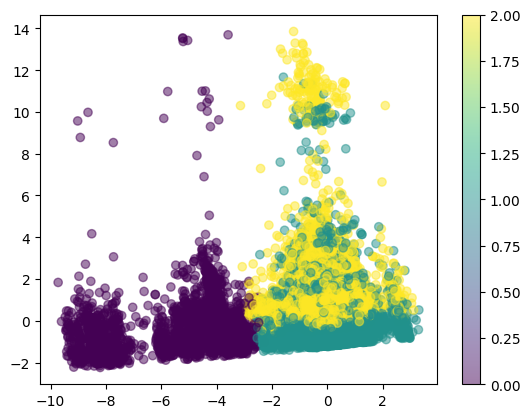

In [52]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(features_scaled)
plt.scatter(coords[:,0], coords[:,1], c=labels, cmap='viridis', alpha=0.5)
plt.colorbar()
plt.show()

In [35]:
# Select clustering features
features = df[['latitude', 'longitude', 'hour', 'duration_seconds']].copy()

print("Feature dataset shape:", features.shape)
print(features.head())


Feature dataset shape: (87458, 4)
    latitude   longitude  hour  duration_seconds
0  29.883056  -97.941111  20.0            2700.0
1  29.384210  -98.581082  21.0            7200.0
2  53.200000   -2.916667  17.0              20.0
3  28.978333  -96.645833  21.0              20.0
4  21.418056 -157.803611  20.0             900.0
